In [1]:
%load_ext autoreload
%autoreload 2

# SRE-DQN vs Nash-DQN Comparison

Trains both Nash-DQN and SRE-DQN on the same multi-agent statistical arbitrage environment
under identical conditions and compares them via:
- Training loss curves
- Policy heatmaps (optimal action over Time × Inventory)
- Reward distributions from simulation rollouts
- Head-to-head performance (Nash vs Nash, SRE vs SRE, Nash vs SRE mixed)

In [19]:

import os
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import pickle
from datetime import datetime
from scipy import stats

from NashRL import run_Nash_Agent, collect_parallel_rollouts
from NashAgent_lib import NashNN
from SREAgent_lib import SreNN
from SREDQN import run_SRE_Agent
from simulation_lib import MarketSimulator
from visualization import draw_heatmap, to_State_mesh, to_State_mesh_sre

np.set_printoptions(precision=4)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)
    return seed


def load_best_checkpoint_into_agent(agent, model_dir):
    checkpoint_path = os.path.join(model_dir, 'best_checkpoint', 'checkpoint.pt')
    device = next(agent.action_net.parameters()).device
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    agent.action_net.load_state_dict(checkpoint['action_net_state_dict'])
    agent.value_net.load_state_dict(checkpoint['value_net_state_dict'])
    if hasattr(agent, 'slow_val_net') and 'slow_val_net_state_dict' in checkpoint:
        agent.slow_val_net.load_state_dict(checkpoint['slow_val_net_state_dict'])
    agent.action_net.eval()
    agent.value_net.eval()
    if hasattr(agent, 'slow_val_net'):
        agent.slow_val_net.eval()
    return checkpoint_path, checkpoint


print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Using device: cuda


## Shared Market Environment

Identical parameters to `NashDQN-Training.ipynb`. Both agents are trained on this same environment.

In [3]:
num_players = 5
kappa = 0.5

sim_dict = {
    'perm_price_impact':  torch.tensor(0.05).cuda().detach(),
    'transaction_cost':   torch.tensor(0.1).cuda().detach(),
    'liquidation_cost':   torch.tensor(0.1).cuda().detach(),
    'running_penalty':    torch.tensor(0.0).cuda().detach(),
    'trans_impact_scale': torch.tensor(0.02).cuda().detach(),
    'trans_impact_decay': torch.tensor(0.5).cuda().detach(),
    'T':                  torch.tensor(5).cuda().detach(),
    'dt':                 torch.tensor(0.5).cuda().detach(),
    'N_agents':           num_players,
    'drift_function':     (lambda x, y: kappa * (10 - y)),
    'volatility':         torch.tensor(0.1).cuda().detach(),
    'init_inv_var':       torch.tensor(50).cuda().detach(),
}

inv_std = sim_dict['volatility'] * torch.sqrt(
    (1 - torch.exp(-2 * kappa * sim_dict['T'])) / (2 * kappa)
)
sim_dict['initial_price_var'] = torch.tensor(inv_std).cuda().detach()

norm_mean = torch.tensor([2.25, 10, 0, 0, 0]).cuda().detach()
norm_std  = torch.tensor([
    1.4361406616345072,
    0.74204157112471332 * 0.2763,
    2.5 * 1.8078,
    0.1 * 0.4225,
    1.0 * 1.6726,
]).cuda().detach()

sim_obj = MarketSimulator(sim_dict, impact='sqrt')
T = sim_dict['T']

print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item())

Agents: 5 | T= 5 | dt= 0.5


/tmp/ipykernel_43854/3308847593.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sim_dict['initial_price_var'] = torch.tensor(inv_std).cuda().detach()


## Hyperparameters

In [4]:

# Shared training config
BASE_SEED = 20260409
NASH_SEED = BASE_SEED
SRE_TRAIN_SEED = BASE_SEED
EVAL_SEED = BASE_SEED + 1

NUM_SIM   = 20000
MAX_STEPS = 10
RV_MIN    = 0.5
RV_MAX    = 2.5
EARLY_STOP = True
EARLY_LIM  = 2000

SRE_EPS_LIST = [0.0, 0.01, 0.1, 0.5, 1.0]
PRIMARY_SRE_EPS = 0.1

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M')


def eps_slug(eps):
    return f'{eps:g}'.replace('.', 'p')


NASH_MODEL_DIR = os.path.join('pt_files', f'nash_{RUN_TAG}')
SRE_MODEL_DIRS = {
    eps: os.path.join('pt_files', f'sre_eps_{eps_slug(eps)}_{RUN_TAG}')
    for eps in SRE_EPS_LIST
}
EVAL_DIR = os.path.join('evaluation', RUN_TAG)
os.makedirs(EVAL_DIR, exist_ok=True)


# Shared network config (valid for both NashNN and SreNN)
NET_KWARGS = dict(
    non_invar_dim=5,
    output_dim=5,
    n_players=num_players,
    max_steps=MAX_STEPS,
    lr=3e-4,
    weighted_adam=True,
    terminal_cost=sim_dict['liquidation_cost'],
    num_moms=0,
    c_cons=50,
    c2_cons=False,
    c3_pos=False,
    layers=4,
)

# SRE-specific hyperparameters
SRE_EPS_DECAY = None   # no epsilon decay
SRE_EPS_REG  = 0.01    # Frobenius regularisation on P_12
SRE_DELTA_MIN = 1e-6   # threshold for SRE correction denominator
SRE_GAMMA    = 1.0     # discount factor (undiscounted to match Nash-DQN)
SRE_EPS_0 = PRIMARY_SRE_EPS  # backwards-compatible alias used in a few later cells

seed_everything(BASE_SEED)

print('Nash model dir:', NASH_MODEL_DIR)
print('Evaluation dir:', EVAL_DIR)
print('Seeds | base:', BASE_SEED, '| nash:', NASH_SEED, '| sre train:', SRE_TRAIN_SEED, '| eval:', EVAL_SEED)
print('NUM_SIM:', NUM_SIM, '| MAX_STEPS:', MAX_STEPS)
print('SRE eps sweep:', SRE_EPS_LIST, '| decay horizon:', SRE_EPS_DECAY)


Nash model dir: pt_files/nash_20260409_1801
Evaluation dir: evaluation/20260409_1801
Seeds | base: 20260409 | nash: 20260409 | sre train: 20260409 | eval: 20260410
NUM_SIM: 20000 | MAX_STEPS: 10
SRE eps sweep: [0.0, 0.01, 0.1, 0.5, 1.0] | decay horizon: None


## Train Nash-DQN

In [5]:

os.makedirs(NASH_MODEL_DIR, exist_ok=True)

seed_everything(NASH_SEED)
nash_agent = NashNN(**NET_KWARGS)

start = time.time()
nash_agent, nash_loss = run_Nash_Agent(
    sim_obj, sim_dict, MAX_STEPS,
    nash_agent=nash_agent,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    path=os.path.join(NASH_MODEL_DIR, ''),
    AN_file_name=os.path.join(NASH_MODEL_DIR, 'Action_Net'),
    VN_file_name=os.path.join(NASH_MODEL_DIR, 'Value_Net'),
)
nash_train_time = time.time() - start
print(f'Nash-DQN training time: {nash_train_time:.1f}s')


CUDA IS AVAILABLE!


/home/wowthecoder/SRE-DQN/continous_action_space/NashRL.py:342: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  q_space = torch.range(start=-10, end=10, step=1)
Nash-DQN:   0%|                                                                               | 0/20000 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/continous_action_space/NashAgent_lib.py:149: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ids = torch.tensor(torch.arange(self.num_players)).tile(num_entries).cuda()
/home/wowthecoder/SRE-DQN/continous_action_space/NashRL.py:435: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Trig

New best loss: 25969.42578125
Saving best checkpoint to disk
Best checkpoint saved
New best loss: 9747.6953125
Saving best checkpoint to disk
Best checkpoint saved


Nash-DQN:   0%|                                                       | 9/20000 [00:02<52:14,  6.38it/s, loss=8044.8789]

New best loss: 6015.49560546875
Saving best checkpoint to disk
Best checkpoint saved


...

Iteration 7800 | Total Loss 95.2200 | V_Loss 47.6302 | A_Loss 47.5898


Nash-DQN:  40%|█████████████████████▌                                | 8001/20000 [08:09<13:45, 14.53it/s, loss=52.9834]

Saving weights to disk
Weights saved to disk
Iteration 8000 | Total Loss 52.9834 | V_Loss 26.6506 | A_Loss 26.3328


Nash-DQN:  41%|█████████████████████▊                                | 8101/20000 [08:15<12:08, 16.33it/s, loss=57.7034]

EARLY STOPPING ON ITERATION 8102
Latest best checkpoint remains in pt_files/nash_20260409_1801/best_checkpoint
Nash-DQN training time: 496.1s


## Train SRE-DQN

In [ ]:

sre_agents = {}
sre_losses = {}
sre_train_times = {}

for eps in SRE_EPS_LIST:
    eps_dir = SRE_MODEL_DIRS[eps]
    os.makedirs(eps_dir, exist_ok=True)

    seed_everything(SRE_TRAIN_SEED)
    sre_agent = SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )

    start = time.time()
    trained_agent, train_loss = run_SRE_Agent(
        sim_obj, sim_dict,
        max_steps=MAX_STEPS,
        sre_agent=sre_agent,
        num_sim=NUM_SIM,
        norm_mean=norm_mean,
        norm_std=norm_std,
        rv_min=RV_MIN,
        rv_max=RV_MAX,
        early_stop=EARLY_STOP,
        early_lim=EARLY_LIM,
        eps_0=eps,
        eps_decay_horizon=SRE_EPS_DECAY,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
        path=os.path.join(eps_dir, ''),
        AN_file_name=os.path.join(eps_dir, f'SRE_Action_Net_eps_{eps_slug(eps)}'),
        VN_file_name=os.path.join(eps_dir, f'SRE_Value_Net_eps_{eps_slug(eps)}'),
    )
    sre_agents[eps] = trained_agent
    sre_losses[eps] = train_loss
    sre_train_times[eps] = time.time() - start
    print(f'SRE-DQN training time (eps={eps:g}): {sre_train_times[eps]:.1f}s')



## Load Best Checkpoints

Run this cell after training, or rerun it later without retraining, to restore the best saved Nash/SRE checkpoints before plotting heatmaps and evaluations.


In [20]:

nash_best_checkpoint_path, nash_best_checkpoint = load_best_checkpoint_into_agent(nash_agent, NASH_MODEL_DIR)
print(
    f"Loaded Nash best checkpoint from iteration {nash_best_checkpoint['iteration']} "
    f"with loss {nash_best_checkpoint['best_loss']:.4f}"
)

sre_best_checkpoint_paths = {}
sre_best_checkpoints = {}
for eps in SRE_EPS_LIST:
    checkpoint_path, checkpoint = load_best_checkpoint_into_agent(sre_agents[eps], SRE_MODEL_DIRS[eps])
    sre_best_checkpoint_paths[eps] = checkpoint_path
    sre_best_checkpoints[eps] = checkpoint
    print(
        f"Loaded SRE best checkpoint (eps={eps:g}) from iteration {checkpoint['iteration']} "
        f"with loss {checkpoint['best_loss']:.4f}"
    )

sre_agent = sre_agents[PRIMARY_SRE_EPS]
sre_loss = sre_losses[PRIMARY_SRE_EPS]
sre_train_time = sre_train_times[PRIMARY_SRE_EPS]
print(f'Primary SRE agent for summary/evaluation cells: eps={PRIMARY_SRE_EPS:g} (best checkpoint restored)')


Loaded Nash best checkpoint from iteration 6101 with loss 35.9072
Loaded SRE best checkpoint (eps=0) from iteration 6101 with loss 35.9075
Loaded SRE best checkpoint (eps=0.01) from iteration 6101 with loss 35.8644
Loaded SRE best checkpoint (eps=0.1) from iteration 6101 with loss 35.5038
Loaded SRE best checkpoint (eps=0.5) from iteration 13856 with loss 22.9477
Loaded SRE best checkpoint (eps=1) from iteration 13856 with loss 20.8066
Primary SRE agent for summary/evaluation cells: eps=0.1 (best checkpoint restored)


## Training Loss Curves

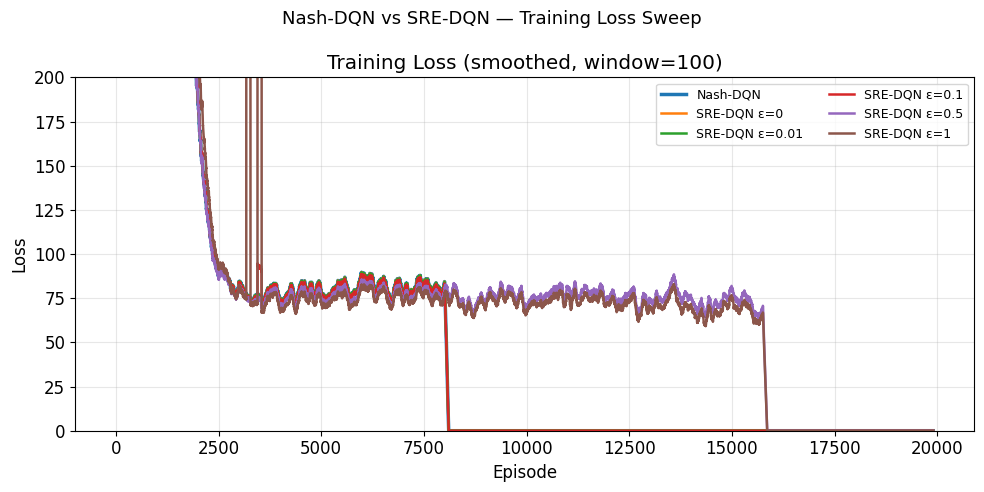

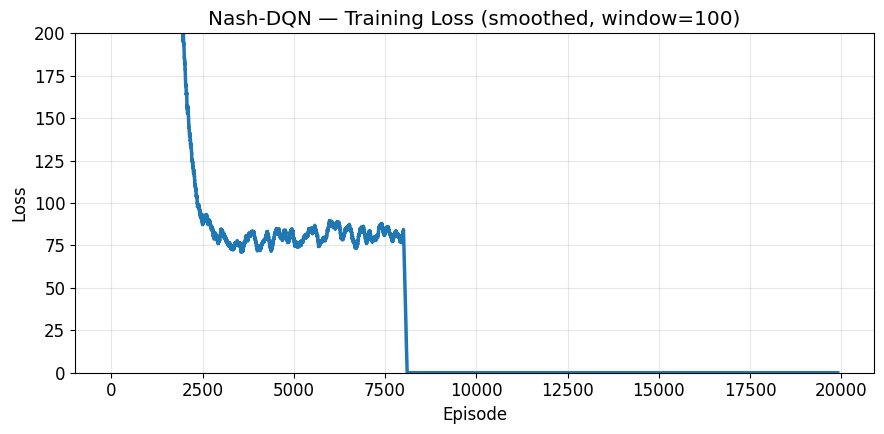

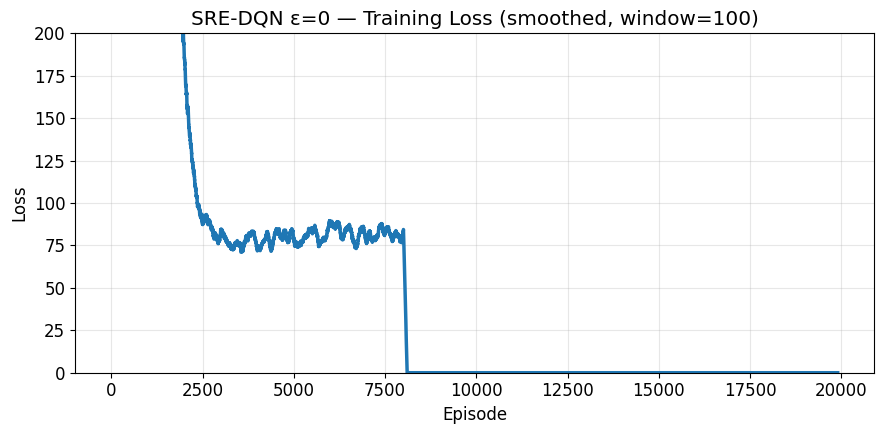

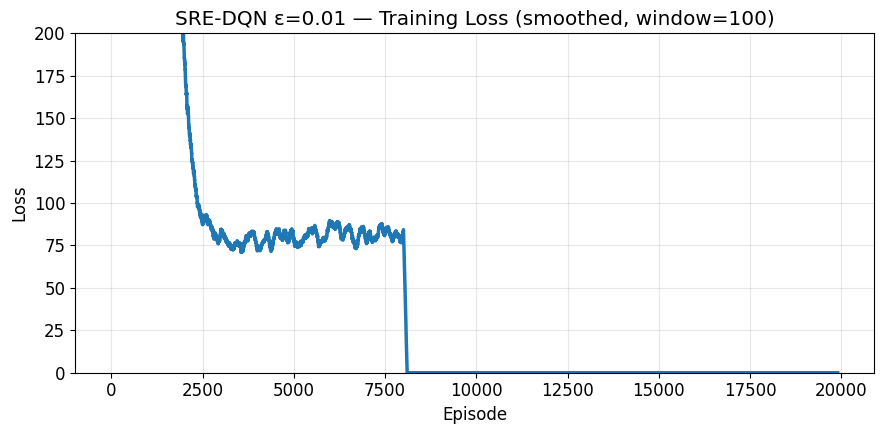

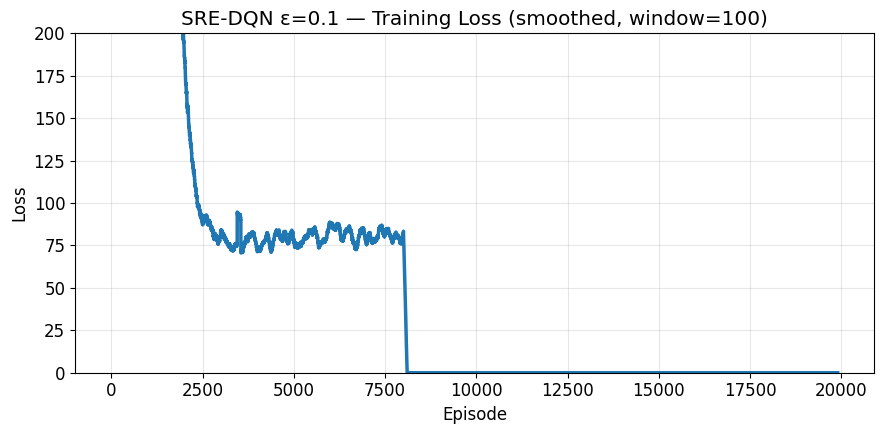

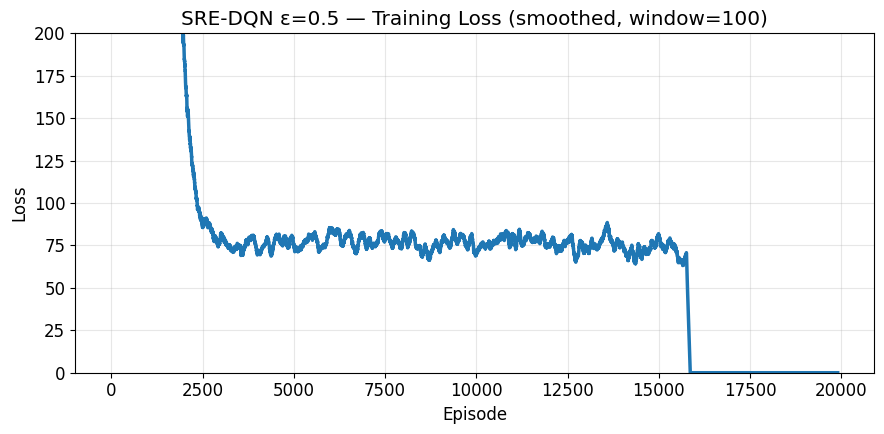

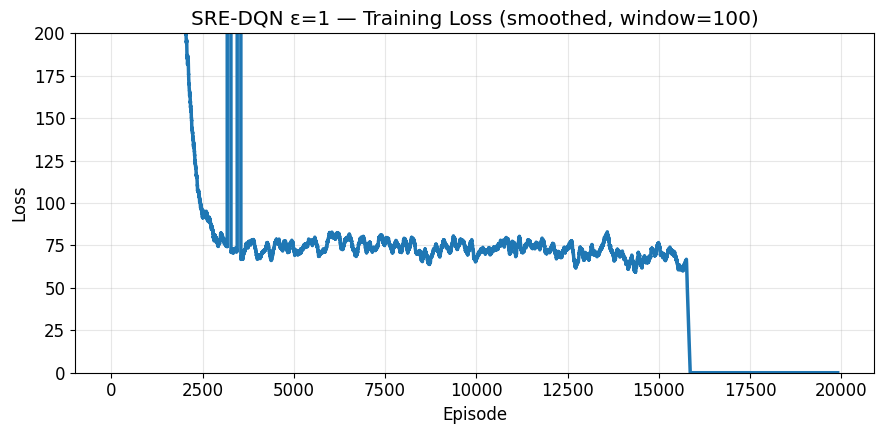

In [15]:

def smooth(arr, window=100):
    arr = np.asarray(arr)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


SMOOTH_WINDOW = 100

# Combined comparison figure
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(nash_loss, window=SMOOTH_WINDOW), linewidth=2.5, label='Nash-DQN')
for eps in SRE_EPS_LIST:
    ax.plot(smooth(sre_losses[eps], window=SMOOTH_WINDOW), linewidth=1.8, label=f'SRE-DQN ε={eps:g}')
ax.set_ylim(0, 200)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title(f'Training Loss (smoothed, window={SMOOTH_WINDOW})')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle('Nash-DQN vs SRE-DQN — Training Loss Sweep', fontsize=13)
plt.tight_layout()
os.makedirs(EVAL_DIR, exist_ok=True)
fig.savefig(os.path.join(EVAL_DIR, 'training_loss_sweep_smoothed.png'), dpi=150, bbox_inches='tight')
plt.show()

# Individual model figures
individual_specs = [
    ('Nash-DQN', nash_loss, 'training_loss_nash_smoothed.png'),
] + [
    (f'SRE-DQN ε={eps:g}', sre_losses[eps], f'training_loss_sre_eps_{eps_slug(eps)}_smoothed.png')
    for eps in SRE_EPS_LIST
]

for label, loss_arr, file_name in individual_specs:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(smooth(loss_arr, window=SMOOTH_WINDOW), linewidth=2.5)
    ax.set_ylim(0, 200)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Loss')
    ax.set_title(f'{label} — Training Loss (smoothed, window={SMOOTH_WINDOW})')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(EVAL_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


## Policy Heatmaps — Nash-DQN

Each panel shows the optimal action (trade rate) as a function of (time remaining, inventory) at a fixed price level.

=== Nash-DQN Policy Heatmaps ===
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


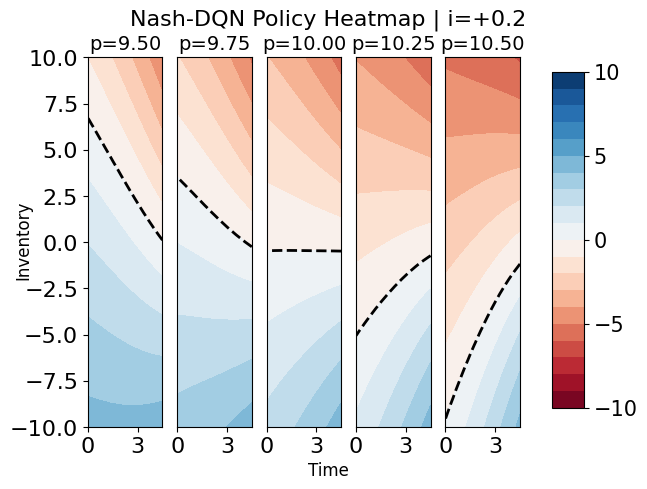

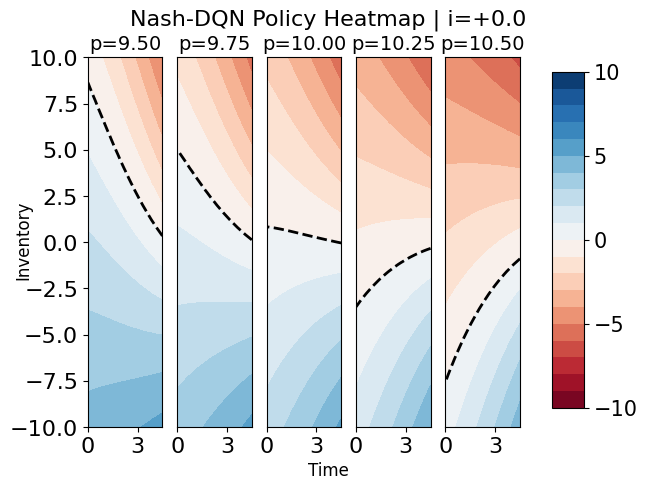

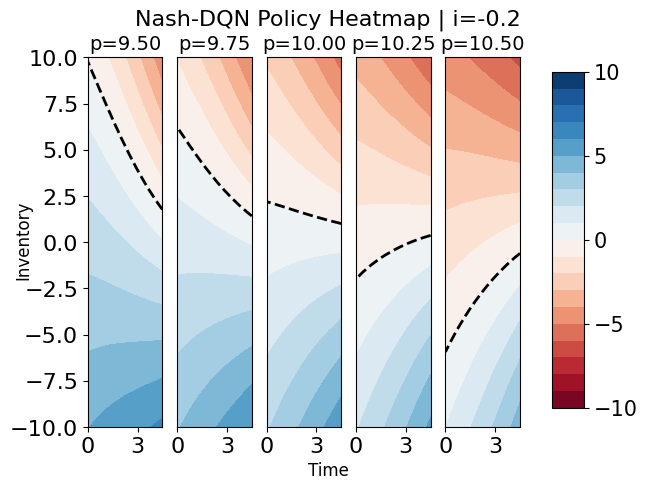

In [23]:

heatmap_kwargs = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5],
    q_range=[-10, 10],
    p_range=[9.5, 10.5],
    n_agents=num_players,
    other_agent_inv=0,
    a_range=[-10, 10],
    T=T,
    norm_mean=norm_mean,
    norm_std=norm_std,
    is_numpy=False,
    norm_input=True,
)

print('=== Nash-DQN Policy Heatmaps ===')
for i_val in [0.2, 0.0, -0.2]:
    draw_heatmap(
        net=nash_agent,
        i_val=i_val,
        file_path=os.path.join(NASH_MODEL_DIR, f'policy_heatmap_nash_i{i_val:+.1f}.png'),
        figure_title=f'Nash-DQN Policy Heatmap | i={i_val:+.1f}',
        **heatmap_kwargs,
    )



## Policy Heatmaps — SRE-DQN Sweep

For each trained SRE agent, this section plots the learned Nash action `μ` across the requested epsilon sweep.


=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


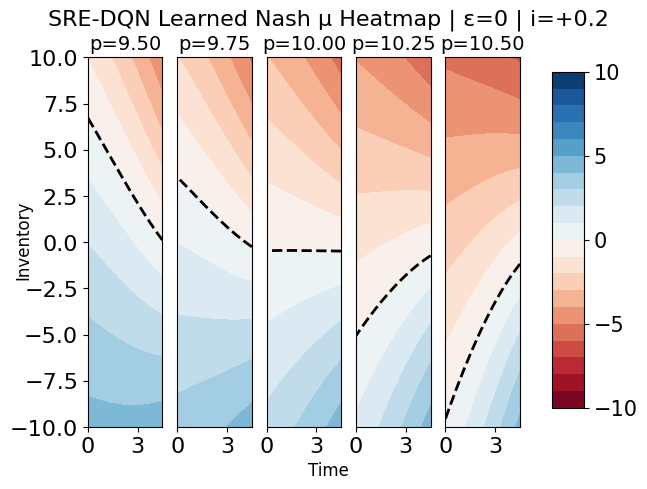

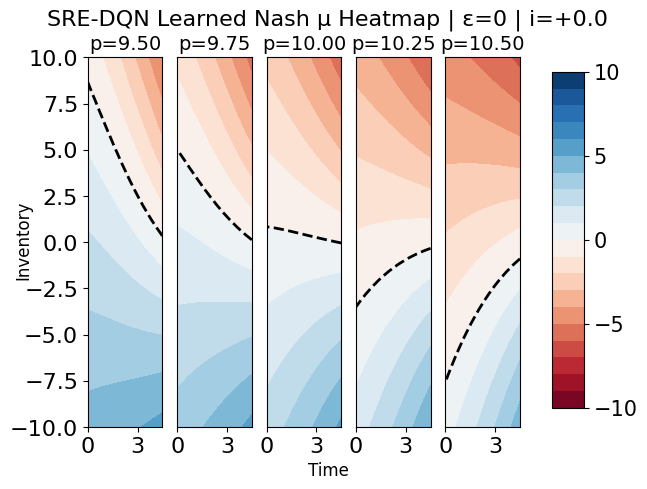

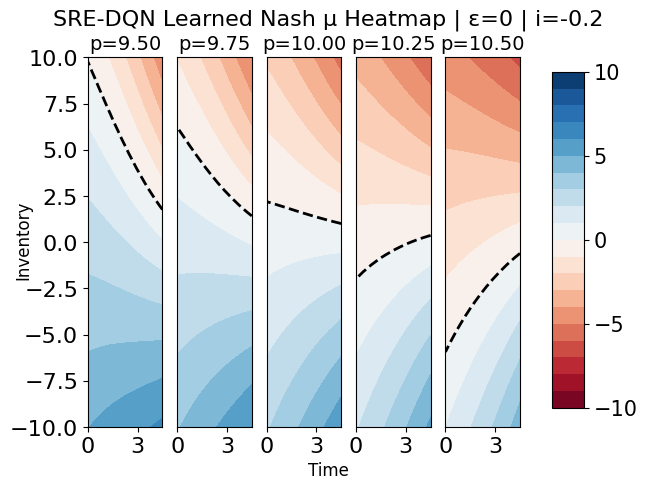

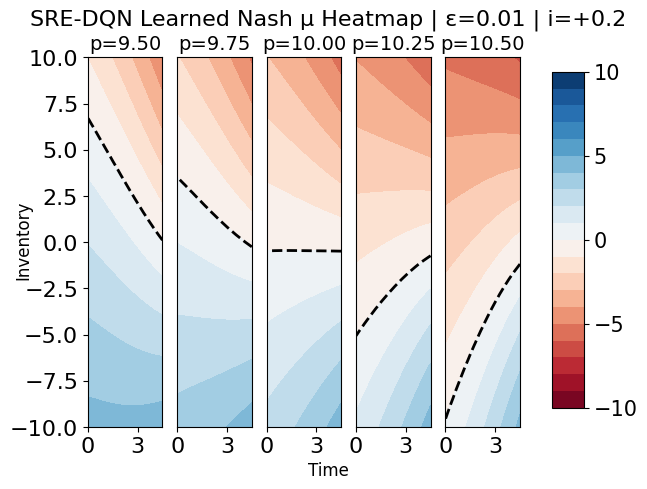

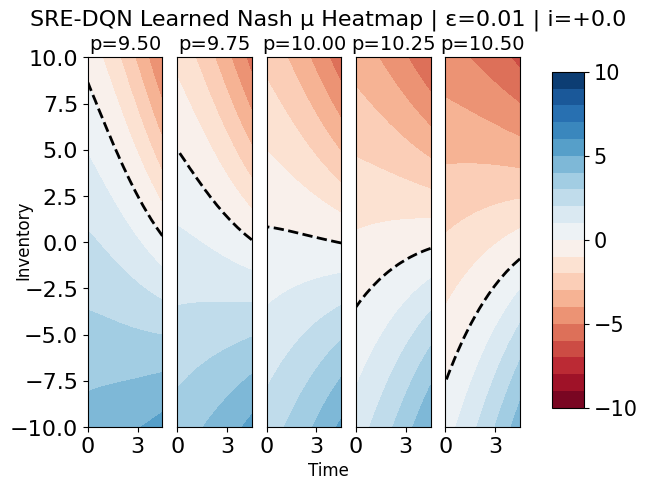

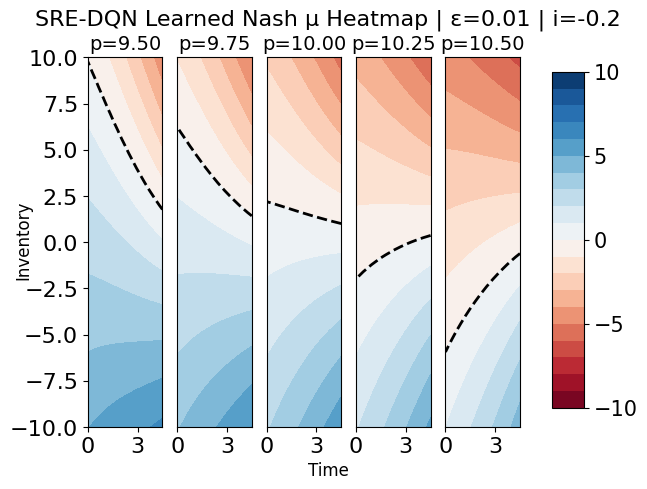

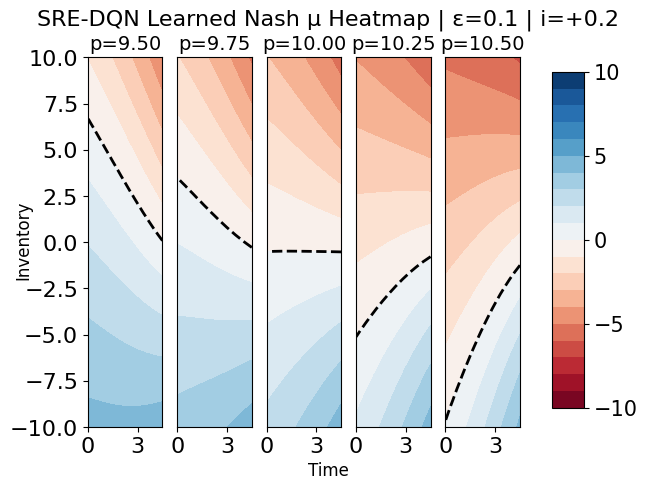

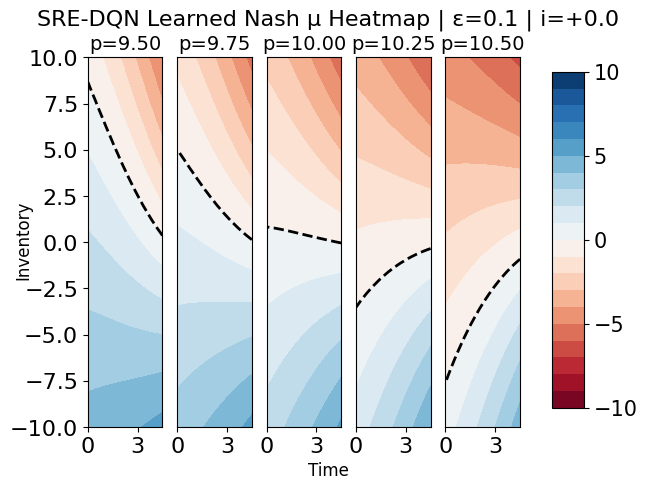

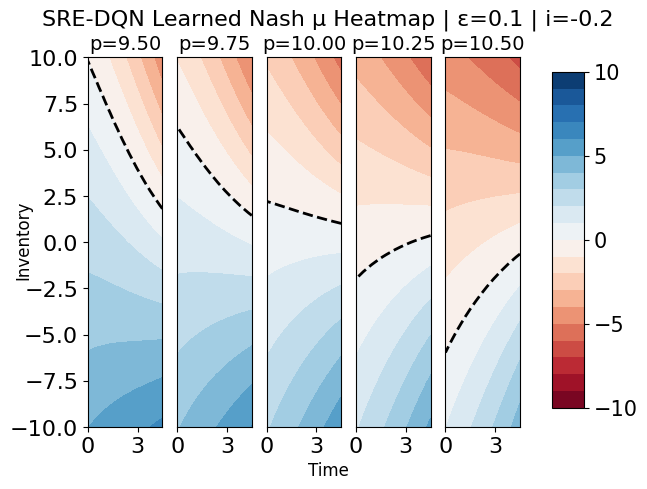

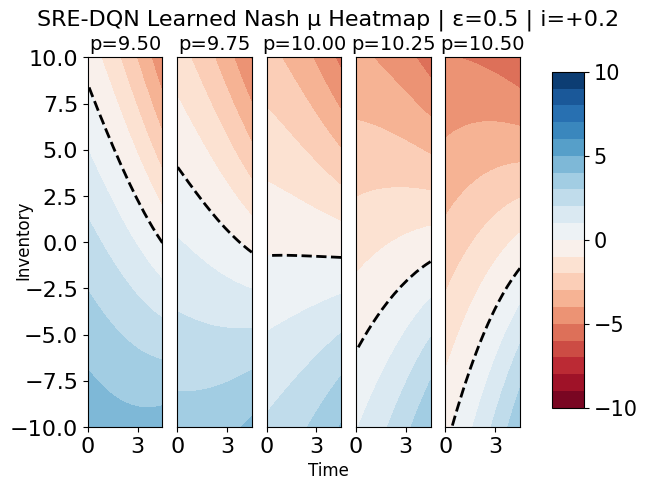

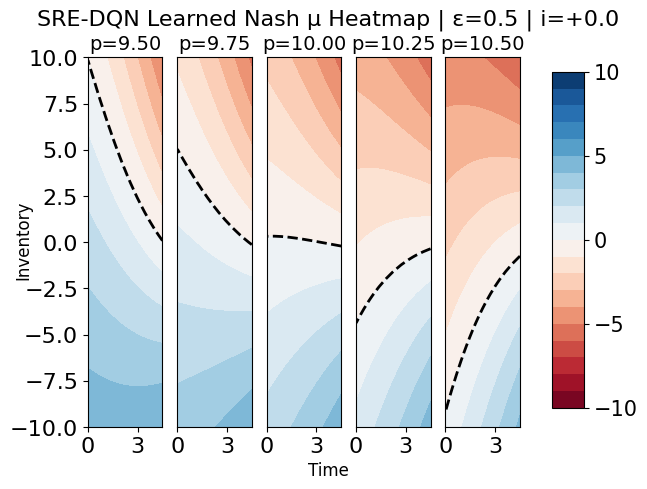

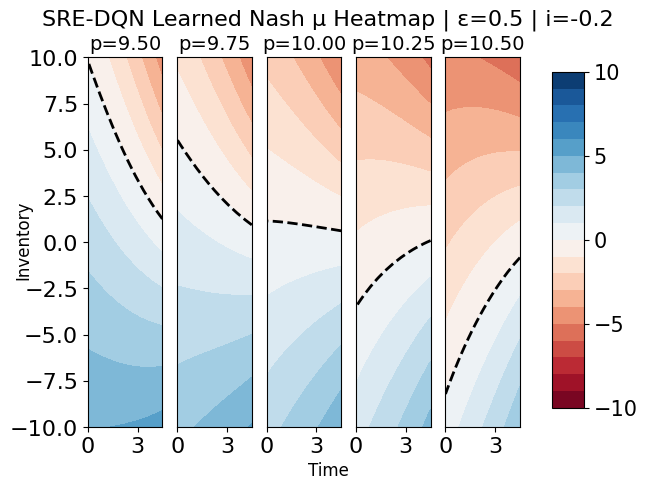

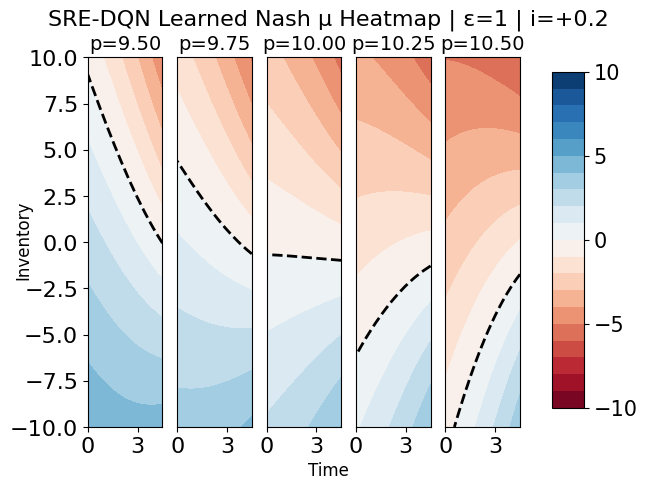

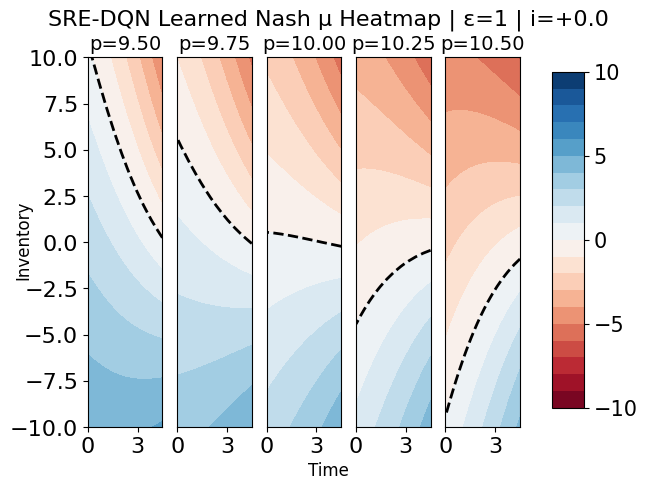

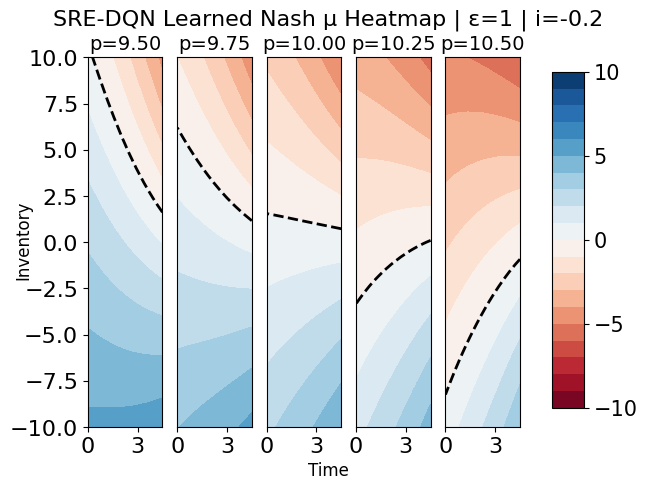

In [24]:

print('=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_mu_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            figure_title=f'SRE-DQN Learned Nash μ Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )



## Policy Heatmaps — SRE-Corrected Action Sweep

These heatmaps show the actual SRE action `μ^SR = μ + ε·correction` for each trained epsilon, with no epsilon decay.


=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


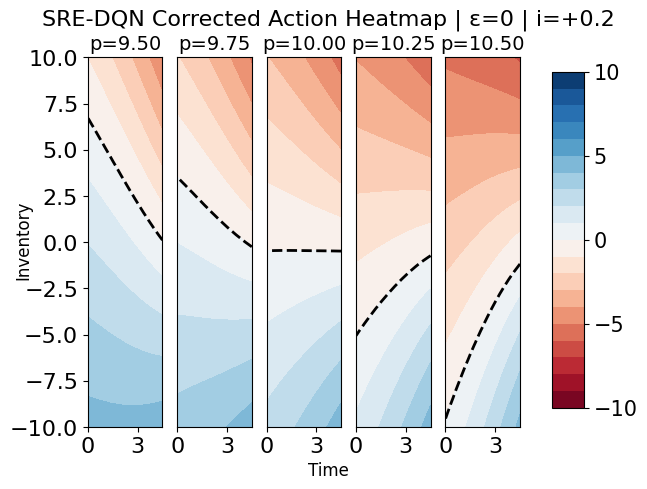

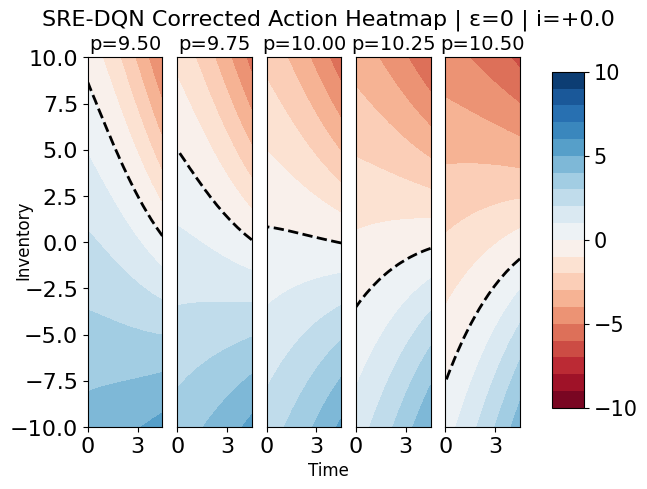

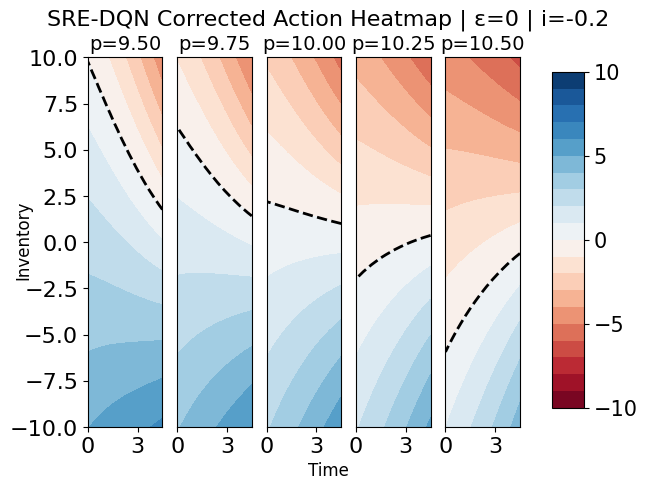

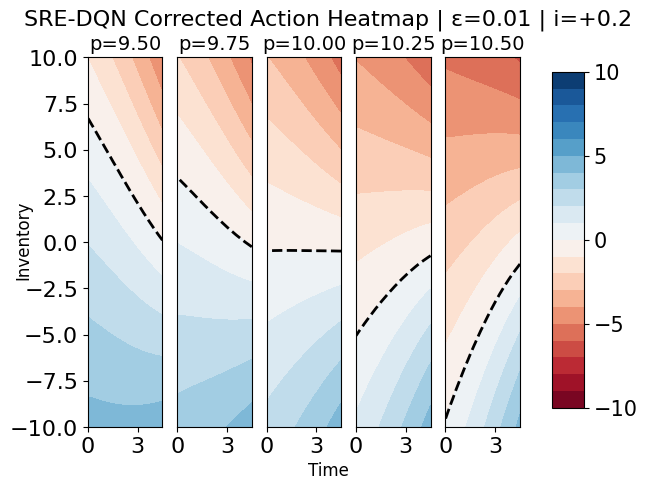

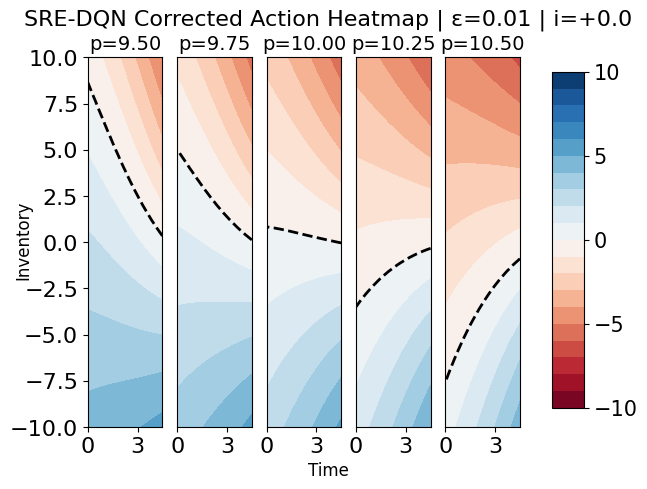

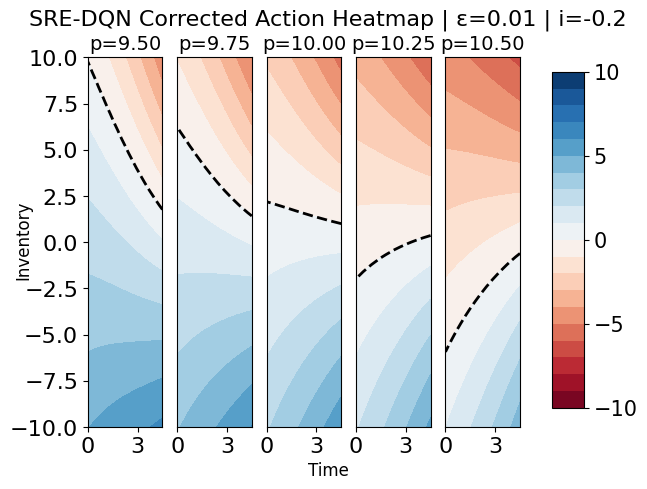

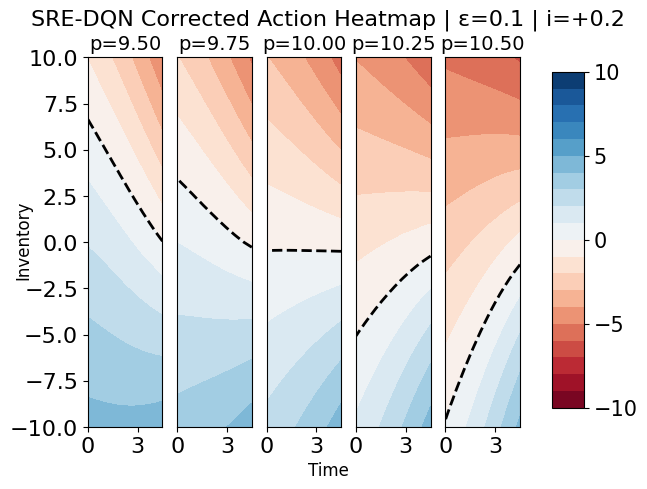

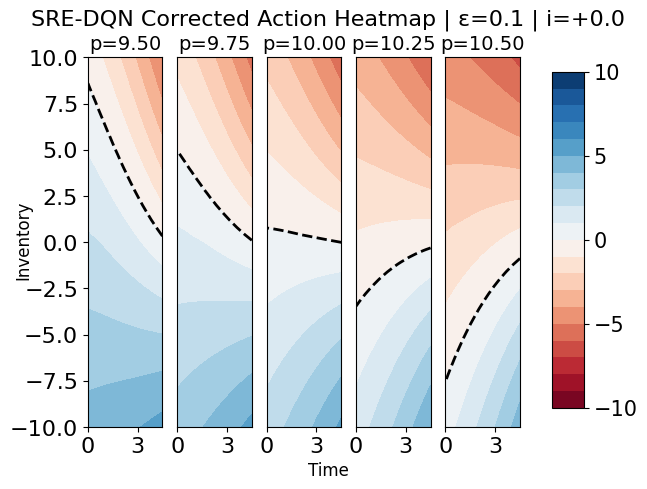

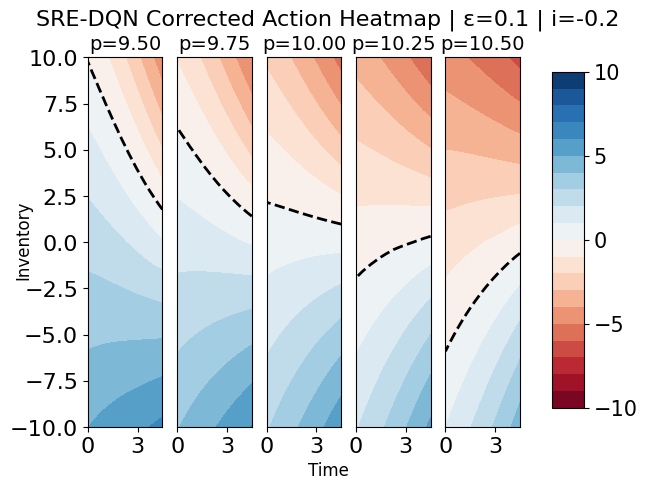

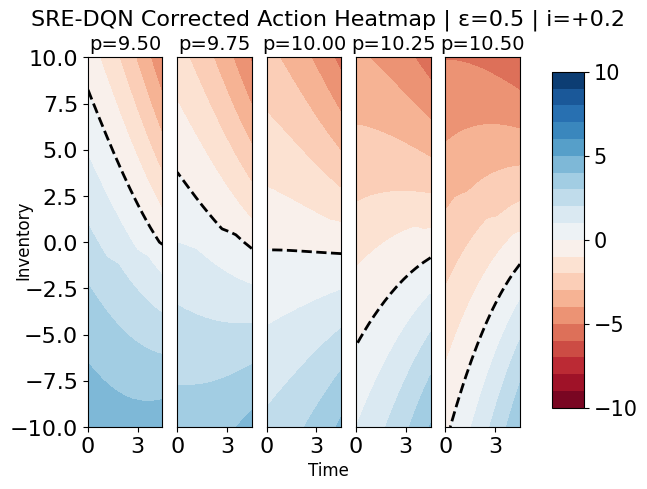

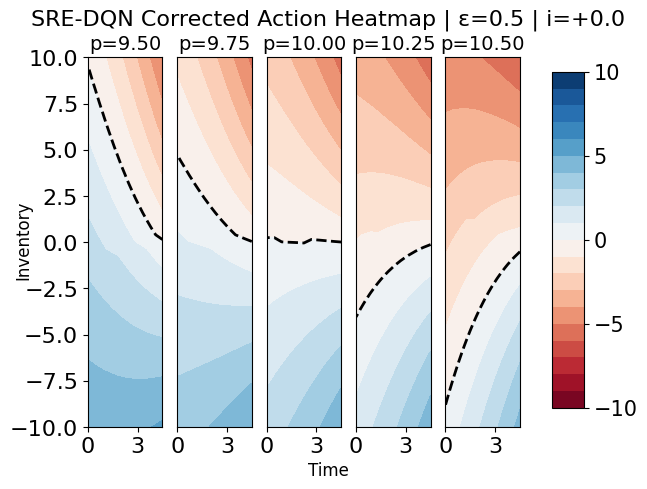

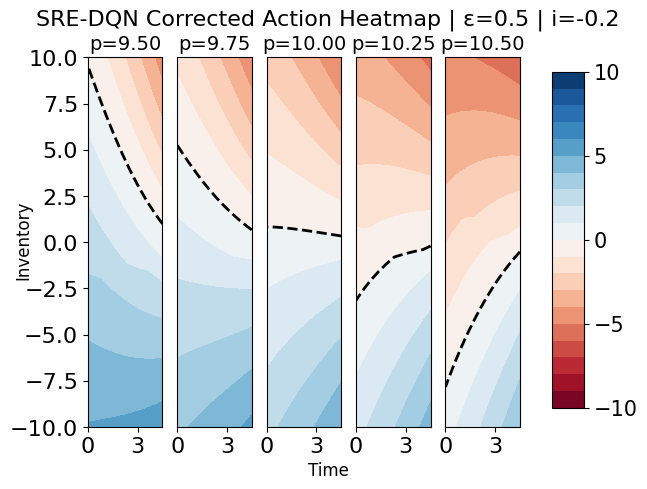

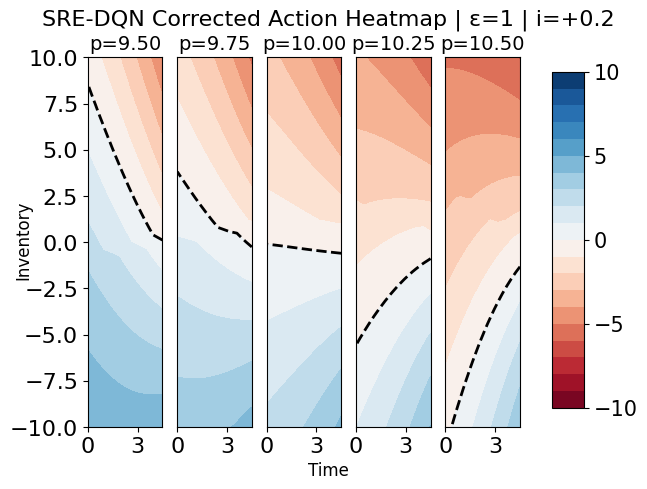

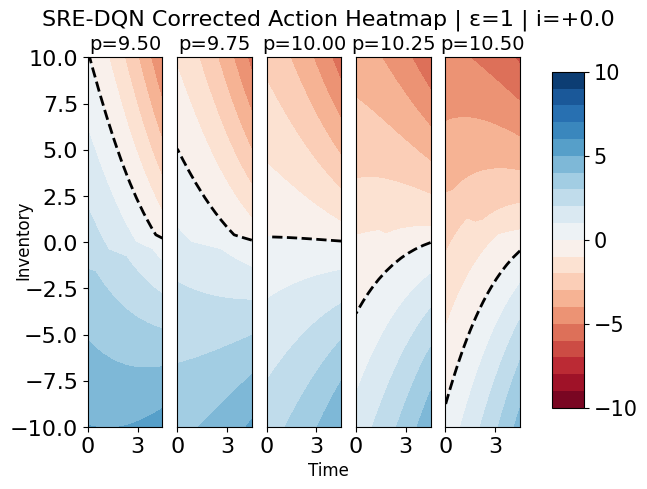

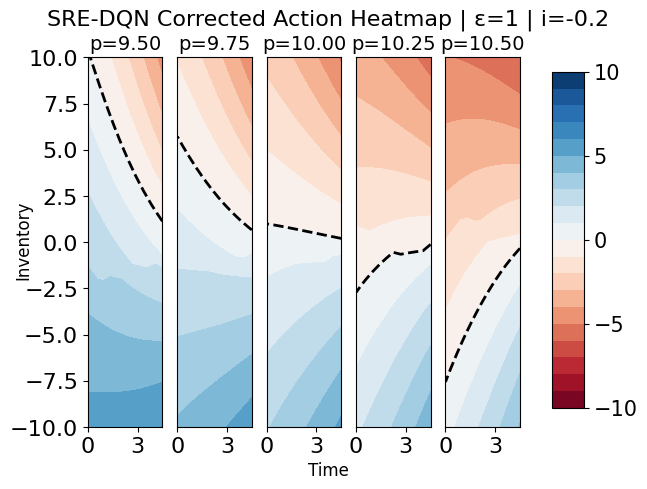

In [25]:

print('=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_corrected_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            mesh_fn=to_State_mesh_sre,
            mesh_kwargs={'eps': eps},
            figure_title=f'SRE-DQN Corrected Action Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )



## Evaluation Rollouts

The post-training evaluation uses these six scenarios with fixed seeds and no epsilon decay:

| Scenario | Agent 0 | Agents 1–4 |
|----------|---------|------------|
| All Nash | Nash | Nash |
| All SRE (ε=0.1) | SRE ε=0.1 | SRE ε=0.1 |
| All SRE (ε=0.01) | SRE ε=0.01 | SRE ε=0.01 |
| All SRE mixed | SRE ε=0.0 | SRE ε in {0.01, 0.1, 0.5, 1.0} |
| Nash vs SRE | Nash | SRE ε=0.1 |
| SRE vs Nash | SRE ε=0.1 | Nash |


In [26]:

NUM_TRIALS = 50
IT_LIM = 500  # episodes per trial


def make_policy_spec(agent, mode, eps=None):
    return {'agent': agent, 'mode': mode, 'eps': eps}


def per_agent_action(spec, states, invt_states):
    if spec['mode'] == 'nash':
        return spec['agent'].predict_action(states, invt_states)[:, 4]
    if spec['mode'] == 'sre':
        return spec['agent'].compute_sre_action(states, invt_states, spec['eps'])
    raise ValueError(f"Unknown policy mode: {spec['mode']}")


def collect_mixed_rewards(sim, norm_mean, norm_std, policy_specs, num_trials, it_lim, seed, desc=None):
    if len(policy_specs) != sim.N:
        raise ValueError(f'Expected {sim.N} policy specs, got {len(policy_specs)}')

    total_episodes = num_trials * it_lim
    n_steps = int(sim.T / sim.dt)
    device = next(policy_specs[0]['agent'].action_net.parameters()).device

    def action_fn(cur_s, cur_ivt):
        state_batch = cur_s.view(total_episodes, sim.N, -1)
        invt_batch = None if cur_ivt is None else cur_ivt.view(total_episodes, sim.N, -1)
        all_actions = []

        for agent_idx, spec in enumerate(policy_specs):
            agent_states = state_batch[:, agent_idx, :]
            agent_invt = None if invt_batch is None else invt_batch[:, agent_idx, :]
            all_actions.append(per_agent_action(spec, agent_states, agent_invt))

        return torch.stack(all_actions, dim=1)

    if desc is not None:
        print(desc)

    seed_everything(seed)
    replay_sample = collect_parallel_rollouts(
        sim_obj=sim,
        max_steps=n_steps,
        mini_batch=total_episodes,
        norm_mean=norm_mean,
        norm_std=norm_std,
        action_fn=action_fn,
        device=device,
    )

    rewards = replay_sample[5].view(n_steps, total_episodes, sim.N)
    rewards = rewards.permute(1, 0, 2).contiguous()
    return rewards.view(num_trials, it_lim, n_steps, sim.N)


nash_spec = make_policy_spec(nash_agent, mode='nash')
sre_001_spec = make_policy_spec(sre_agents[0.01], mode='sre', eps=0.01)
sre_01_spec = make_policy_spec(sre_agents[0.1], mode='sre', eps=0.1)

scenario_specs = [
    ('All Nash', [nash_spec for _ in range(num_players)]),
    ('All SRE (eps=0.1)', [sre_01_spec for _ in range(num_players)]),
    ('All SRE (eps=0.01)', [sre_001_spec for _ in range(num_players)]),
    (
        'All SRE Mixed (0,0.01,0.1,0.5,1.0)',
        [make_policy_spec(sre_agents[eps], mode='sre', eps=eps) for eps in SRE_EPS_LIST],
    ),
    ('Nash vs SRE (agent 0 Nash)', [nash_spec] + [sre_01_spec for _ in range(num_players - 1)]),
    ('SRE vs Nash (agent 0 SRE)', [sre_01_spec] + [nash_spec for _ in range(num_players - 1)]),
]

scenario_rewards = {}
for scenario_name, policy_specs in scenario_specs:
    scenario_rewards[scenario_name] = collect_mixed_rewards(
        sim_obj,
        norm_mean,
        norm_std,
        policy_specs,
        NUM_TRIALS,
        IT_LIM,
        seed=EVAL_SEED,
        desc=f'Collecting {scenario_name} rollouts...',
    )

all_nash_rewards = scenario_rewards['All Nash']
all_sre_01_rewards = scenario_rewards['All SRE (eps=0.1)']
all_sre_001_rewards = scenario_rewards['All SRE (eps=0.01)']
all_sre_mixed_rewards = scenario_rewards['All SRE Mixed (0,0.01,0.1,0.5,1.0)']
nash_vs_sre_rewards = scenario_rewards['Nash vs SRE (agent 0 Nash)']
sre_vs_nash_rewards = scenario_rewards['SRE vs Nash (agent 0 SRE)']

print('Done.')


Done.


## Reward Distribution Histograms

/tmp/ipykernel_43854/1958618457.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


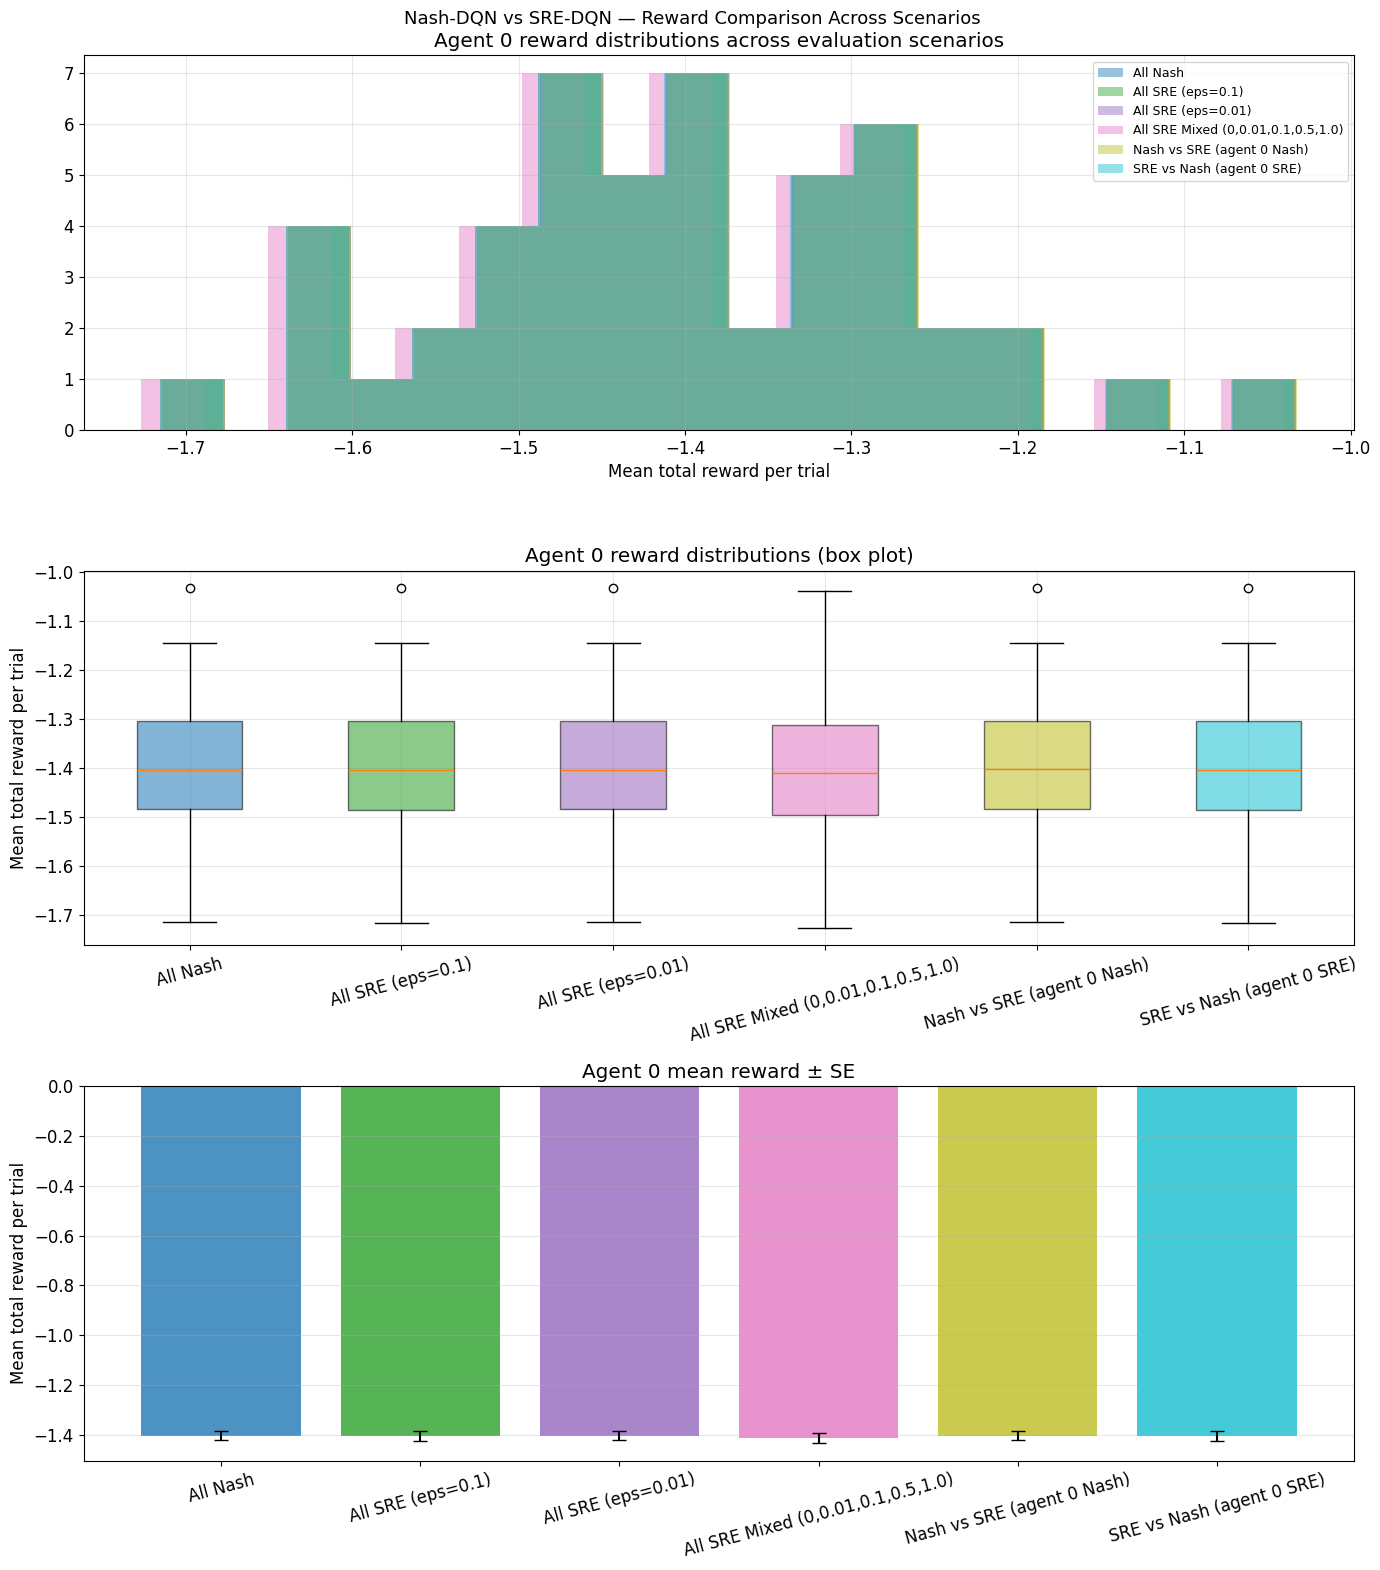

In [27]:

def agent0_mean_total_reward(rewards):
    """Mean total reward for agent 0, averaged over episodes, per trial.
    rewards shape: [num_trials, it_lim, n_steps, n_agents]
    """
    return rewards.sum(dim=2)[..., 0].mean(dim=1).cpu().numpy()


scenario_agent0_rewards = {
    name: agent0_mean_total_reward(rewards)
    for name, rewards in scenario_rewards.items()
}

scenario_names = list(scenario_agent0_rewards.keys())
scenario_arrays = [scenario_agent0_rewards[name] for name in scenario_names]
colors = plt.cm.tab10(np.linspace(0, 1, len(scenario_names)))

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Histogram overlay
ax = axes[0]
for color, name in zip(colors, scenario_names):
    ax.hist(scenario_agent0_rewards[name], bins=18, alpha=0.45, label=name, color=color)
ax.set_title('Agent 0 reward distributions across evaluation scenarios')
ax.set_xlabel('Mean total reward per trial')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Box plots
ax = axes[1]
box = ax.boxplot(
    scenario_arrays,
    labels=scenario_names,
    patch_artist=True,
)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
ax.set_title('Agent 0 reward distributions (box plot)')
ax.set_ylabel('Mean total reward per trial')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3)

# Summary bar chart
ax = axes[2]
means = [arr.mean() for arr in scenario_arrays]
errs = [arr.std() / np.sqrt(NUM_TRIALS) for arr in scenario_arrays]
ax.bar(scenario_names, means, yerr=errs, capsize=5, color=colors, alpha=0.8)
ax.set_title('Agent 0 mean reward ± SE')
ax.set_ylabel('Mean total reward per trial')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3, axis='y')

fig.suptitle('Nash-DQN vs SRE-DQN — Reward Comparison Across Scenarios', fontsize=13)
plt.tight_layout()
os.makedirs(EVAL_DIR, exist_ok=True)
fig.savefig(os.path.join(EVAL_DIR, 'reward_comparison_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()


## Statistical Comparison

In [13]:

def describe(arr, name):
    return {
        'scenario': name,
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'median': float(np.median(arr)),
        'min': float(arr.min()),
        'max': float(arr.max()),
    }


rows = [describe(arr, name) for name, arr in scenario_agent0_rewards.items()]

print(f"{'Scenario':<36} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
print('-' * 84)
for row in rows:
    print(
        f"{row['scenario']:<36} {row['mean']:8.4f} {row['std']:8.4f} "
        f"{row['median']:8.4f} {row['min']:8.4f} {row['max']:8.4f}"
    )

print()

t_stat, p_val = stats.ttest_ind(
    scenario_agent0_rewards['All Nash'],
    scenario_agent0_rewards['All SRE (eps=0.1)'],
    equal_var=False,
)
print(f"Welch t-test (All Nash vs All SRE eps=0.1): t={t_stat:.3f}, p={p_val:.4f}")

t_stat2, p_val2 = stats.ttest_ind(
    scenario_agent0_rewards['All Nash'],
    scenario_agent0_rewards['All SRE (eps=0.01)'],
    equal_var=False,
)
print(f"Welch t-test (All Nash vs All SRE eps=0.01): t={t_stat2:.3f}, p={p_val2:.4f}")

t_stat3, p_val3 = stats.ttest_ind(
    scenario_agent0_rewards['SRE vs Nash (agent 0 SRE)'],
    scenario_agent0_rewards['Nash vs SRE (agent 0 Nash)'],
    equal_var=False,
)
print(f"Welch t-test (SRE-vs-Nash vs Nash-vs-SRE): t={t_stat3:.3f}, p={p_val3:.4f}")

win_rate = float((
    scenario_agent0_rewards['SRE vs Nash (agent 0 SRE)']
    > scenario_agent0_rewards['Nash vs SRE (agent 0 Nash)']
).mean())
print(f'Win rate: SRE agent 0 beats Nash agent 0 in {win_rate * 100:.1f}% of trials')


Scenario                                 Mean      Std   Median      Min      Max
------------------------------------------------------------------------------------
All Nash                              -1.3804   0.1653  -1.3618  -1.7375  -1.0904
All SRE (eps=0.1)                     -1.3808   0.1653  -1.3621  -1.7371  -1.0907
All SRE (eps=0.01)                    -1.3805   0.1653  -1.3618  -1.7375  -1.0905
All SRE Mixed (0,0.01,0.1,0.5,1.0)    -1.3873   0.1656  -1.3693  -1.7452  -1.1080
Nash vs SRE (agent 0 Nash)            -1.3794   0.1653  -1.3606  -1.7360  -1.0899
SRE vs Nash (agent 0 SRE)             -1.3818   0.1654  -1.3633  -1.7386  -1.0912

Welch t-test (All Nash vs All SRE eps=0.1): t=0.008, p=0.9935
Welch t-test (All Nash vs All SRE eps=0.01): t=0.000, p=0.9998
Welch t-test (SRE-vs-Nash vs Nash-vs-SRE): t=-0.055, p=0.9562
Win rate: SRE agent 0 beats Nash agent 0 in 0.0% of trials


## Save Results

In [14]:

comparison_dict = {
    'nash_loss': nash_loss,
    'sre_losses': sre_losses,
    'scenario_rewards': scenario_rewards,
    'scenario_agent0_rewards': scenario_agent0_rewards,
    'config': {
        'BASE_SEED': BASE_SEED,
        'NASH_SEED': NASH_SEED,
        'SRE_TRAIN_SEED': SRE_TRAIN_SEED,
        'EVAL_SEED': EVAL_SEED,
        'NUM_SIM': NUM_SIM,
        'NUM_TRIALS': NUM_TRIALS,
        'IT_LIM': IT_LIM,
        'SRE_EPS_LIST': SRE_EPS_LIST,
        'PRIMARY_SRE_EPS': PRIMARY_SRE_EPS,
        'SRE_EPS_DECAY': SRE_EPS_DECAY,
        'SRE_EPS_REG': SRE_EPS_REG,
        'nash_train_time': nash_train_time,
        'sre_train_times': sre_train_times,
        'nash_best_checkpoint_path': nash_best_checkpoint_path,
        'sre_best_checkpoint_paths': sre_best_checkpoint_paths,
        'use_best_checkpoint_for_plots_and_eval': True,
        'nash_model_dir': NASH_MODEL_DIR,
        'sre_model_dirs': SRE_MODEL_DIRS,
        'evaluation_dir': EVAL_DIR,
    },
}

out_path = os.path.join(EVAL_DIR, 'sre_vs_nash_comparison.pickle')
with open(out_path, 'wb') as f:
    pickle.dump(comparison_dict, f)
print('Saved comparison results to:', out_path)


Saved comparison results to: evaluation/20260409_1801/sre_vs_nash_comparison.pickle
